In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("ggplot")

In [4]:
funds = pd.read_csv("../data/processed/01_fund_master_cleaned.csv")

nav = pd.read_csv("../data/processed/02_nav_history_cleaned.csv")

investors = pd.read_csv("../data/processed/08_investor_transactions_cleaned.csv")

In [5]:
print("FUNDS")
print(funds.columns.tolist())

print("\nNAV")
print(nav.columns.tolist())

print("\nINVESTORS")
print(investors.columns.tolist())

FUNDS
['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code']

NAV
['amfi_code', 'date', 'nav']

INVESTORS
['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']


In [6]:
nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(
    ["amfi_code", "date"]
)

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
    .pct_change()
)

In [7]:
var_report = (
    nav.groupby("amfi_code")["daily_return"]
    .apply(lambda x: np.percentile(x.dropna(), 5))
    .reset_index()
)

var_report.columns = [
    "amfi_code",
    "VaR_95"
]

var_report.head()

,amfi_code,VaR_95
0,100016,-0.014364
1,100025,-0.003793
2,100033,-0.019034
3,101206,-0.013282
4,101207,-0.026021


In [8]:
cvar_list = []

for fund in nav["amfi_code"].unique():

    returns = nav[
        nav["amfi_code"] == fund
    ]["daily_return"].dropna()

    var = np.percentile(
        returns,
        5
    )

    cvar = returns[
        returns <= var
    ].mean()

    cvar_list.append(
        [fund, cvar]
    )

cvar_df = pd.DataFrame(
    cvar_list,
    columns=["amfi_code", "CVaR"]
)

cvar_df.head()

,amfi_code,CVaR
0,100016,-0.018060
1,100025,-0.004994
2,100033,-0.023456
3,101206,-0.017439
4,101207,-0.032459


In [9]:
var_cvar_report = var_report.merge(
    cvar_df,
    on="amfi_code"
)

var_cvar_report.head()

,amfi_code,VaR_95,CVaR
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [10]:
var_cvar_report.to_csv(
    "../reports/var_cvar_report.csv",
    index=False
)

In [11]:
var_cvar_report.describe()

,amfi_code,VaR_95,CVaR
count,40.000000,40.000000,40.000000
mean,120247.000000,-0.014711,-0.018580
std,14534.998667,0.006821,0.008476
min,100016.000000,-0.026859,-0.032459
25%,118632.750000,-0.018394,-0.023133
50%,119551.500000,-0.014376,-0.018185
75%,120842.250000,-0.013247,-0.016572
max,149324.000000,-0.000222,-0.000373


In [12]:
top5_funds = nav["amfi_code"].unique()[:5]

print(top5_funds)

[100016 100025 100033 101206 101207]


In [13]:
for fund in top5_funds:
    count = len(nav[nav["amfi_code"] == fund])
    print(f"Fund {fund}: {count} records")

Fund 100016: 1150 records
Fund 100025: 1150 records
Fund 100033: 1150 records
Fund 101206: 1150 records
Fund 101207: 1150 records


In [14]:
fund = top5_funds[0]

df = nav[nav["amfi_code"] == fund].copy()

df.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [15]:
df["rolling_mean"] = (
    df["daily_return"]
    .rolling(window=90)
    .mean()
)

df[["date", "daily_return", "rolling_mean"]].tail()

,date,daily_return,rolling_mean
1145,2026-05-25,-0.004227,-0.000610
1146,2026-05-26,-0.005819,-0.000592
1147,2026-05-27,-0.009367,-0.000770
1148,2026-05-28,0.000152,-0.000737
1149,2026-05-29,-0.012410,-0.000754


In [16]:
df["rolling_std"] = (
    df["daily_return"]
    .rolling(window=90)
    .std()
)

df[["date", "rolling_mean", "rolling_std"]].tail()

,date,rolling_mean,rolling_std
1145,2026-05-25,-0.000610,0.009824
1146,2026-05-26,-0.000592,0.009812
1147,2026-05-27,-0.000770,0.009824
1148,2026-05-28,-0.000737,0.009822
1149,2026-05-29,-0.000754,0.009841


In [17]:
df["rolling_sharpe"] = (
    df["rolling_mean"]
    /
    df["rolling_std"]
) * np.sqrt(252)

df[
    ["date",
     "rolling_mean",
     "rolling_std",
     "rolling_sharpe"]
].tail()

,date,rolling_mean,rolling_std,rolling_sharpe
1145,2026-05-25,-0.000610,0.009824,-0.986168
1146,2026-05-26,-0.000592,0.009812,-0.957388
1147,2026-05-27,-0.000770,0.009824,-1.244102
1148,2026-05-28,-0.000737,0.009822,-1.191463
1149,2026-05-29,-0.000754,0.009841,-1.215738


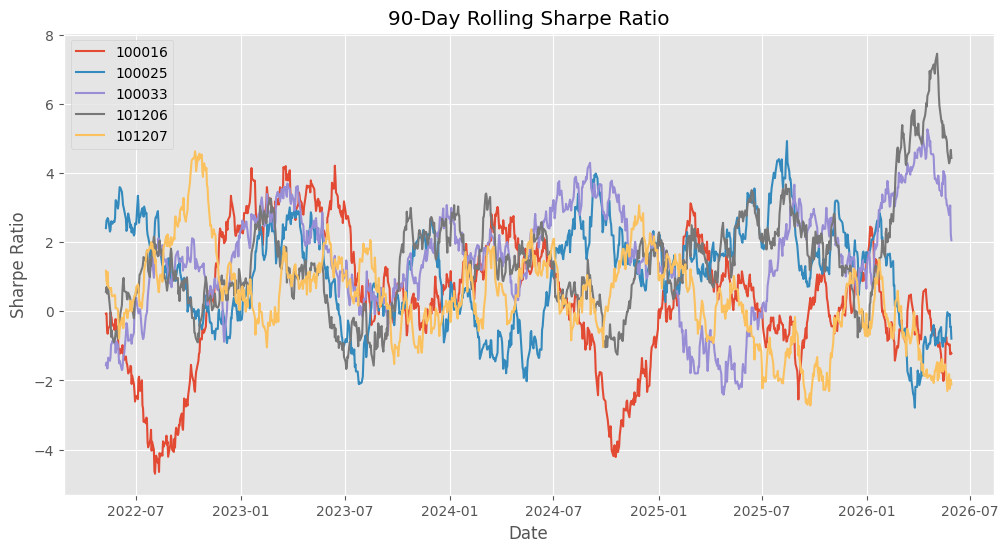

In [18]:
top5_funds = nav["amfi_code"].unique()[:5]

plt.figure(figsize=(12,6))

for fund in top5_funds:

    df = nav[nav["amfi_code"] == fund].copy()

    rolling_mean = (
        df["daily_return"]
        .rolling(90)
        .mean()
    )

    rolling_std = (
        df["daily_return"]
        .rolling(90)
        .std()
    )

    rolling_sharpe = (
        rolling_mean /
        rolling_std
    ) * np.sqrt(252)

    plt.plot(
        df["date"],
        rolling_sharpe,
        label=str(fund)
    )

plt.title("90-Day Rolling Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.legend()
plt.grid(True)

plt.savefig(
    "../reports/rolling_sharpe_chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Rolling Sharpe Ratio Analysis

A 90-day rolling Sharpe Ratio was computed for the top 5 mutual funds using daily NAV returns.

Observations:
- Higher Sharpe values indicate better risk-adjusted performance.
- Negative Sharpe values indicate periods where risk exceeded returns.
- Rolling analysis helps identify changes in fund performance over time.


In [19]:
investors.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [20]:
investors.columns.tolist()

['investor_id',
 'transaction_date',
 'amfi_code',
 'transaction_type',
 'amount_inr',
 'state',
 'city',
 'city_tier',
 'age_group',
 'gender',
 'annual_income_lakh',
 'payment_mode',
 'kyc_status']

In [21]:
investors["transaction_date"] = pd.to_datetime(
    investors["transaction_date"]
)

In [22]:
first_txn = (
    investors.groupby("investor_id")
    ["transaction_date"]
    .min()
    .reset_index()
)

first_txn.head()

,investor_id,transaction_date
0,INV000001,2024-11-04
1,INV000002,2024-03-29
2,INV000003,2024-07-16
3,INV000004,2024-03-16
4,INV000005,2024-04-27


In [23]:
first_txn["cohort_year"] = (
    first_txn["transaction_date"]
    .dt.year
)

first_txn.head()

,investor_id,transaction_date,cohort_year
0,INV000001,2024-11-04,2024
1,INV000002,2024-03-29,2024
2,INV000003,2024-07-16,2024
3,INV000004,2024-03-16,2024
4,INV000005,2024-04-27,2024


In [24]:
investors = investors.merge(
    first_txn[
        ["investor_id", "cohort_year"]
    ],
    on="investor_id",
    how="left"
)

In [25]:
cohort_analysis = (
    investors.groupby("cohort_year")
    .agg(
        total_investors=("investor_id", "nunique"),
        total_investment=("amount_inr", "sum"),
        avg_investment=("amount_inr", "mean")
    )
    .reset_index()
)

cohort_analysis

,cohort_year,total_investors,total_investment,avg_investment
0,2024,4803,3491125187,107422.541832
1,2025,197,30455243,109158.577061


In [26]:
cohort_analysis.to_csv(
    "../reports/cohort_analysis.csv",
    index=False
)

In [27]:
cohort_analysis.head()

,cohort_year,total_investors,total_investment,avg_investment
0,2024,4803,3491125187,107422.541832
1,2025,197,30455243,109158.577061


In [28]:
investors = investors.sort_values(
    ["investor_id", "transaction_date"]
)

In [29]:
investors["gap_days"] = (
    investors.groupby("investor_id")
    ["transaction_date"]
    .diff()
    .dt.days
)

In [30]:
investors[
    ["investor_id",
     "transaction_date",
     "gap_days"]
].head(20)

,investor_id,transaction_date,gap_days
19621,INV000001,2024-11-04,NaN
24079,INV000001,2025-01-14,71.0
24448,INV000001,2025-01-19,5.0
5650,INV000002,2024-03-29,NaN
12522,INV000002,2024-07-14,107.0
16803,INV000002,2024-09-21,69.0
17587,INV000002,2024-10-03,12.0
24661,INV000002,2025-01-23,112.0
31881,INV000002,2025-05-17,114.0
12652,INV000003,2024-07-16,NaN


In [31]:
sip_continuity = (
    investors.groupby("investor_id")
    ["gap_days"]
    .mean()
    .reset_index()
)

In [32]:
sip_continuity["risk_flag"] = np.where(
    sip_continuity["gap_days"] > 35,
    "At Risk",
    "Active"
)

In [33]:
sip_continuity.head()

,investor_id,gap_days,risk_flag
0,INV000001,38.000,At Risk
1,INV000002,82.800,At Risk
2,INV000003,238.000,At Risk
3,INV000004,53.375,At Risk
4,INV000005,52.000,At Risk


In [34]:
sip_continuity.to_csv(
    "../reports/sip_continuity.csv",
    index=False
)

In [35]:
sip_continuity["risk_flag"].value_counts()

risk_flag
At Risk    4305
Active      695
Name: count, dtype: int64

## SIP Continuity Analysis

Investor transaction history was analysed to identify gaps between investments.

Method:
- Calculated transaction gap in days
- Computed average gap per investor
- Investors with average gaps greater than 35 days were flagged as "At Risk"

Purpose:
- Detect potential SIP discontinuation
- Support investor retention strategies

In [37]:
scorecard = pd.read_csv(
    "../data/processed/fund_scorecard.csv"
)

scorecard.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,...,expense_ratio_pct,morningstar_rating,risk_grade,anomaly,return_rank,sharpe_rank,alpha_rank,expense_rank,drawdown_rank,fund_score
0,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,...,0.72,4,Very High,False,2.0,19.5,22.5,5.5,11.0,11.90
1,120843,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,Flexi Cap,Regular,15.74,15.65,13.50,13.80,1.85,...,1.45,5,Moderately High,False,11.0,12.0,3.5,22.0,21.0,12.40
2,120842,Kotak Emerging Equity Fund - Regular - Growth,Kotak Mahindra MF,Mid Cap,Regular,17.12,18.23,17.75,16.32,1.91,...,1.56,4,High,False,7.0,15.0,2.0,33.0,16.0,12.80
3,101207,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,Small Cap,Regular,24.93,22.38,23.80,20.54,1.84,...,1.53,5,Very High,False,3.0,24.5,5.0,28.5,14.0,13.70
4,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,...,1.43,5,Very High,False,1.0,18.0,20.0,21.0,33.0,15.25


In [38]:
scorecard.columns.tolist()

['amfi_code',
 'scheme_name',
 'fund_house',
 'category',
 'plan',
 'return_1yr_pct',
 'return_3yr_pct',
 'return_5yr_pct',
 'benchmark_3yr_pct',
 'alpha',
 'beta',
 'sharpe_ratio',
 'sortino_ratio',
 'std_dev_ann_pct',
 'max_drawdown_pct',
 'aum_crore',
 'expense_ratio_pct',
 'morningstar_rating',
 'risk_grade',
 'anomaly',
 'return_rank',
 'sharpe_rank',
 'alpha_rank',
 'expense_rank',
 'drawdown_rank',
 'fund_score']